<a href="https://colab.research.google.com/github/lkmn-ai/linear-regression-notes/blob/main/91_Regularization_Autos_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pd.set_option('display.max_columns', None)

## 1. Problem Statement

In [ ]:
To predict the car price using various variables

Dependent Variables : Price

Independent Variable : 'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg'

## 2. Data Gathering

In [ ]:
df_autos = pd.read_csv('autos_dataset.csv')
df_autos.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [ ]:
df_autos.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [ ]:
df_autos.head().T

,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,?,?,?,164,164
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
engine-location,front,front,front,front,front
wheel-base,88.6,88.6,94.5,99.8,99.4


In [ ]:
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

## 3. Exploratory Data Analysis

In [ ]:
df_autos.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [ ]:
df_autos[df_autos['normalized-losses'] == '?'].shape

(41, 26)

In [ ]:
df_autos[df_autos == '?'].shape

(205, 26)

In [ ]:
df_autos.replace({'?':np.nan}, inplace=True)
df_autos.isna().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [ ]:
df_autos.isna().mean()*100 # will convert into %

symboling             0.00000
normalized-losses    20.00000
make                  0.00000
fuel-type             0.00000
aspiration            0.00000
num-of-doors          0.97561
body-style            0.00000
drive-wheels          0.00000
engine-location       0.00000
wheel-base            0.00000
length                0.00000
width                 0.00000
height                0.00000
curb-weight           0.00000
engine-type           0.00000
num-of-cylinders      0.00000
engine-size           0.00000
fuel-system           0.00000
bore                  1.95122
stroke                1.95122
compression-ratio     0.00000
horsepower            0.97561
peak-rpm              0.97561
city-mpg              0.00000
highway-mpg           0.00000
price                 1.95122
dtype: float64

In [ ]:
df_autos.duplicated().sum()

0

### 3.1 symboling

In [ ]:
df_autos['symboling']

0      3
1      3
2      1
3      2
4      2
      ..
200   -1
201   -1
202   -1
203   -1
204   -1
Name: symboling, Length: 205, dtype: int64

In [ ]:
df_autos['symboling'].nunique()

6

In [ ]:
df_autos['symboling'].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64

In [ ]:
df_autos.groupby('symboling')[['price']].mean()

,price
symboling,
-2,15781.666667
-1,17330.681818
0,14361.567164
1,9780.444444
2,10109.281250
3,17221.296296


In [ ]:
df_autos['symboling'] = np.where(df_autos['symboling']== -2, -1, df_autos['symboling'])
df_autos['symboling'].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    25
Name: count, dtype: int64

### 3.2 normalized-losses

In [ ]:
df_autos['normalized-losses']

0      NaN
1      NaN
2      NaN
3      164
4      164
      ... 
200     95
201     95
202     95
203     95
204     95
Name: normalized-losses, Length: 205, dtype: object

mean >> If outliers are not present
median >> If outliers are present
KNN Imputer/Mice Imputer/Simple Imputer >> Small dataset with more than 10-15%

Null Value Ratio >> Fill Ratio

30% or more >> Drop Column

In [ ]:
df_autos.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.848780,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220,13207.126829
std,1.217342,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443,7868.768212
min,-1.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10595.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [ ]:
df_autos['normalized-losses'] = df_autos['normalized-losses'].astype(float)
df_autos['normalized-losses'].mean()

122.0

In [ ]:
df_autos['normalized-losses'].median()

115.0

<Axes: >

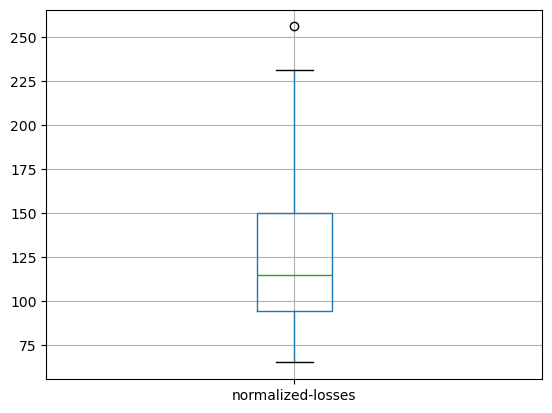

In [ ]:
df_autos.boxplot('normalized-losses')

In [ ]:
df_autos['normalized-losses'] = df_autos['normalized-losses'].fillna(df_autos['normalized-losses'].median())
df_autos['normalized-losses'] = df_autos['normalized-losses'].astype(int)

### 3.3 make

In [ ]:
df_autos['make']

0      alfa-romero
1      alfa-romero
2      alfa-romero
3             audi
4             audi
          ...     
200          volvo
201          volvo
202          volvo
203          volvo
204          volvo
Name: make, Length: 205, dtype: object

In [ ]:
df_autos['make'].nunique()

22

In [ ]:
df_autos['make'].value_counts()

make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
volkswagen       12
subaru           12
peugot           11
volvo            11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
jaguar            3
chevrolet         3
alfa-romero       3
renault           2
mercury           1
Name: count, dtype: int64

### 3.4 Fuel-Type

In [ ]:
df_autos['fuel-type']

0         gas
1         gas
2         gas
3         gas
4         gas
        ...  
200       gas
201       gas
202       gas
203    diesel
204       gas
Name: fuel-type, Length: 205, dtype: object

In [ ]:
df_autos['fuel-type'].value_counts()

fuel-type
gas       185
diesel     20
Name: count, dtype: int64

In [ ]:
df_autos['fuel-type'].replace({'diesel':0, 'gas':1}, inplace=True)
df_autos['fuel-type']

0      1
1      1
2      1
3      1
4      1
      ..
200    1
201    1
202    1
203    0
204    1
Name: fuel-type, Length: 205, dtype: int64

### 3.5 Aspiration

In [ ]:
df_autos['aspiration']

0        std
1        std
2        std
3        std
4        std
       ...  
200      std
201    turbo
202      std
203    turbo
204    turbo
Name: aspiration, Length: 205, dtype: object

In [ ]:
df_autos['aspiration'].value_counts()

aspiration
std      168
turbo     37
Name: count, dtype: int64

In [ ]:
df_autos['aspiration'].replace({'turbo':0, 'std':1}, inplace=True)
df_autos['aspiration']

0      1
1      1
2      1
3      1
4      1
      ..
200    1
201    0
202    1
203    0
204    0
Name: aspiration, Length: 205, dtype: int64

### 3.6 Num-of-Doors

In [ ]:
df_autos['num-of-doors'].value_counts()

num-of-doors
four    114
two      89
Name: count, dtype: int64

In [ ]:
df_autos['num-of-doors'].value_counts().to_dict()

{'four': 114, 'two': 89}

In [ ]:
df_autos['num-of-doors'].replace({'four':4, 'two':2}, inplace=True) # why we are giving 4 and 2 coz, people when using app they will filter out and better searchability, instead of 0 and 1 s.
df_autos['num-of-doors']

0      2.0
1      2.0
2      2.0
3      4.0
4      4.0
      ... 
200    4.0
201    4.0
202    4.0
203    4.0
204    4.0
Name: num-of-doors, Length: 205, dtype: float64

In [ ]:
df_autos['num-of-doors'].fillna(df_autos['num-of-doors'].mode()[0], inplace=True)
df_autos['num-of-doors'] = df_autos['num-of-doors'].astype(int)

### 3.7 Body-Style

In [ ]:
df_autos['body-style'].value_counts()

body-style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [ ]:
df_autos.groupby('body-style')['price'].mean()

body-style
convertible    21890.500000
hardtop        22208.500000
hatchback      10050.285714
sedan          14433.656250
wagon          12371.960000
Name: price, dtype: float64

In [ ]:
df_autos = pd.get_dummies(df_autos, columns=['body-style'], drop_first=True, dtype=int)
df_autos

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
0,3,115,alfa-romero,1,1,2,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495,False,False,False,False
1,3,115,alfa-romero,1,1,2,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500,False,False,False,False
2,1,115,alfa-romero,1,1,2,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500,False,True,False,False
3,2,164,audi,1,1,4,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950,False,False,True,False
4,2,164,audi,1,1,4,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,1,1,4,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845,False,False,True,False
201,-1,95,volvo,1,0,4,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045,False,False,True,False
202,-1,95,volvo,1,1,4,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485,False,False,True,False
203,-1,95,volvo,0,0,4,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.4,23.0,106,4800,26,27,22470,False,False,True,False


### 3.8 Drive-Wheels

In [ ]:
df_autos['drive-wheels'].value_counts()

In [ ]:
df_autos['drive-wheels'].value_counts().to_dict()

In [ ]:
df_autos['price'] = pd.to_numeric(df_autos['price'], errors='coerce') # Group by 'drive-wheels' and calculate the mean price
mean_prices = df_autos.groupby('drive-wheels')['price'].mean()
mean_prices

In [ ]:
df_autos['drive-wheels'].replace({'fwd': 0, 'rwd': 2, '4wd': 1}, inplace=True)
df_autos['drive-wheels']

### 3.9 Engine-Location

In [ ]:
df_autos['engine-location'].value_counts()

In [ ]:
df_autos['engine-location'].replace({'front': 1, 'rear': 0,}, inplace=True)
df_autos['engine-location']

### 3.10 Wheel-Base

In [ ]:
df_autos['wheel-base']

In [ ]:
df_autos['wheel-base'].plot(kind = 'kde')

In [ ]:
df_autos['wheel-base'].skew()

In [ ]:
df_autos.boxplot('wheel-base')

In [ ]:
sns.boxplot(df_autos['wheel-base'])

In [ ]:
df_autos[df_autos['wheel-base'] >= 114]

In [ ]:
df_autos['wheel-base']  = np.where(df_autos['wheel-base'] >= 114, df_autos['wheel-base'].median(), df_autos['wheel-base'])

### 3.11 Length

In [ ]:
sns.kdeplot(df_autos['length'])

In [ ]:
df_autos['length'].skew()

### 3.12 Width

In [ ]:
sns.kdeplot(df_autos['width'])

In [ ]:
df_autos['width'].skew()

In [ ]:
sns.kdeplot(df_autos['width'])

In [ ]:
sns.boxplot(df_autos['width'])

In [ ]:
df_autos[df_autos['width'] >= 71].shape

In [ ]:
df_autos['width'] = np.where(df_autos['width'] >= 71, df_autos['width'].median(), df_autos['width'])

### 3.13 Height

In [ ]:
sns.kdeplot(df_autos['height'])

In [ ]:
df_autos['height'].skew()

### 3.14 Curb-Weight

In [ ]:
sns.kdeplot(df_autos['curb-weight'])

In [ ]:
sns.boxplot(df_autos['curb-weight'])

## 3.15 Engine-Type

In [ ]:
df_autos.columns

In [ ]:
df_autos['engine-type'].value_counts()

In [ ]:
df_autos = pd.get_dummies(df_autos, columns=['engine-type'], drop_first=True)
df_autos

### 3.16 Num-of-Cylinders

In [ ]:
df_autos['num-of-cylinders'].value_counts()

In [ ]:
df_autos['num-of-cylinders'].value_counts().to_dict()

In [ ]:
df_autos.groupby('num-of-cylinders')['price'].mean().sort_values()

In [ ]:
df_autos['num-of-cylinders'].replace({'four': 4,
                                         'six': 6,
                                         'five': 5,
                                         'eight': 8,
                                         'two': 2,
                                         'three': 3,
                                         'twelve': 12}, inplace=True)

### 3.17 Engine-Size

In [ ]:
sns.kdeplot(df_autos['engine-size'])

In [ ]:
sns.boxplot(df_autos['engine-size'])

In [ ]:
df_autos[df_autos['engine-size'] >= 200].shape

In [ ]:
df_autos['engine-size'] = np.where(df_autos['engine-size'] >= 200, df_autos['engine-size'].median(), df_autos['engine-size'])

### 3.18 Fuel-System

In [ ]:
df_autos['fuel-system'].value_counts()

In [ ]:
df_autos = pd.get_dummies(df_autos, columns=['fuel-system'], drop_first=True)
df_autos

### 3.19 Bore

In [ ]:
df_autos['bore']

In [ ]:
df_autos['bore'] = df_autos['bore'].astype(float)
df_autos['bore'].median()

In [ ]:
df_autos['bore'].mean()

In [ ]:
df_autos['bore'].fillna(df_autos['bore'].mean(),inplace=True)

### 3.20 Stroke

In [ ]:
df_autos['stroke']

In [ ]:
df_autos['stroke'] = df_autos['stroke'].astype(float)
df_autos['stroke'].median()

In [ ]:
df_autos[['stroke']].describe()

In [ ]:
df_autos['stroke'].fillna(df_autos['stroke'].median(),inplace=True)

### 3.21 Compression Ratio

In [ ]:
df_autos['compression-ratio']

In [ ]:
sns.kdeplot(df_autos['compression-ratio'])

In [ ]:
sns.boxplot(df_autos['compression-ratio'])

In [ ]:
df_autos['compression-ratio'] = np.where(df_autos['compression-ratio'] >= 12, df_autos['compression-ratio'].median(),
                                         df_autos['compression-ratio'])

## 3.22 horsepower

In [ ]:
df_autos['horsepower'] = df_autos['horsepower'].astype(float)
df_autos['horsepower'].fillna(df_autos['horsepower'].mean(), inplace=True)
df_autos['horsepower'] = df_autos['horsepower'].astype(int)

### 3.23 Peak-RPM

In [ ]:
df_autos['peak-rpm']

In [ ]:
df_autos['peak-rpm'] = df_autos['peak-rpm'].astype(float)
df_autos['peak-rpm'].fillna(df_autos['peak-rpm'].mean(), inplace=True)
df_autos['peak-rpm'] = df_autos['peak-rpm'].astype(int)

In [ ]:
sns.kdeplot(df_autos['peak-rpm'])

In [ ]:
df_autos['peak-rpm'].skew()

### 3.24 City-MPG

In [ ]:
sns.kdeplot(df_autos['city-mpg'])

In [ ]:
df_autos['city-mpg'].skew()

In [ ]:
sns.boxplot(df_autos['city-mpg'])

In [ ]:
df_autos['city-mpg'] = np.where(df_autos['city-mpg'] >= 45, df_autos['city-mpg'].median(),
                                         df_autos['city-mpg'])

### 3.25 HIghway MPG

In [ ]:
sns.kdeplot(df_autos['highway-mpg'])

In [ ]:
df_autos['highway-mpg'].skew()

### 3.26 Price

In [ ]:
df_autos['price'] = df_autos['price'].astype(float)
df_autos['price'] = df_autos['price'].fillna(df_autos['price'].mean())
df_autos['price'] = df_autos['price'].astype(int)

In [ ]:
df_autos.info()

In [ ]:
df_autos[df_autos.select_dtypes(bool).columns] = df_autos.select_dtypes(bool).astype(int)
df_autos

### 5. Feature Selection

In [ ]:
1. Correlation:
    Cont vs Cont >> Pearson corr
    Cat vs Cat >> Chi-Square Test
    Cat vs Cont >> ANOVA    # f_classif, f_oneway, f_regression


| Variable 1  | Variable 2  | Statistical Test    | Purpose                                                               |
| ----------- | ----------- | ------------------- | --------------------------------------------------------------------- |
| Continuous  | Continuous  | Pearson Correlation | Measure the strength and direction of a linear relationship           |
| Categorical | Categorical | Chi-Square Test     | Check whether two categorical variables are associated                |
| Categorical | Continuous  | ANOVA               | Compare the mean of a continuous variable across different categories |


In [ ]:
df_autos.drop('make',axis=1).corr()['price'].sort_values()

In [ ]:
fs1 = pd.DataFrame(df_autos.drop('make',axis=1).corr()['price'].sort_values().reset_index())
fs1[fs1['price'].between(-0.2, 0.2)]['index'].values

In [ ]:
df_autos.corr()['price'].head(22).sort_values().head(4).index

In [ ]:
df_autos.corr()['price'].head(22).sort_values().tail(9).index

In [ ]:
df_autos.corr()['price'].head(22).sort_values()[4:-9].index

## 6. Model Training

### Train Test Split

In [ ]:
x = df_autos.drop(['aspiration', 'fuel-type', 'peak-rpm', 'compression-ratio', 'symboling','make',
       'num-of-doors', 'stroke', 'normalized-losses', 'height','price'], axis = 1)

y = df_autos['price']

In [ ]:
x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size=0.2, random_state=2)

In [ ]:
def model_building(algo, x , y):
    model = algo
    model.fit(x,y)
    return model

linear_reg = model_building(LinearRegression(), x_train, y_train)
linear_reg

## 7. Evaluation

In [ ]:
y_pred = linear_reg.predict(x_test)
y_pred[:5]

In [ ]:
y_test[:5]

In [ ]:
def evaluation(string, model, ind_var, y_act):
    print(string.center(50,'*'))
    pred = model.predict(ind_var)

    mse = mean_squared_error(y_act, pred)
    print('MSE :', mse)

    rmse = np.sqrt(mse)
    print('RMSE :', rmse)

    mae = mean_absolute_error(y_act, pred)
    print('MAE :', mae)

    r_squared = r2_score(y_act, pred)
    print('R2_score:', r_squared)

    adj_r2 = 1 - (((1-r_squared)*(ind_var.shape[0] - 1))/(ind_var.shape[0]-ind_var.shape[1]-1))
    print('Adjusted R2 :', adj_r2)

evaluation('Test Data Evaluation', linear_reg, x_test, y_test)
print()

evaluation('Train Data Evaluation', linear_reg, x_train, y_train)

## Ridge Regression

In [ ]:
ridge_model = model_building(Ridge(alpha=5), x_train, y_train)
ridge_model

In [ ]:
evaluation('Test Data Evaluation', ridge_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', ridge_model, x_train, y_train)

## Lasso Regression

In [ ]:
lasso_model = model_building(Lasso(alpha=0.10), x_train, y_train)
lasso_model

In [ ]:
evaluation('Test Data Evaluation', lasso_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', lasso_model, x_train, y_train)

In [ ]:
linear_reg.coef_

In [ ]:
ridge_model.coef_

In [ ]:
lasso_model.coef_

In [ ]:
pd.Series(ridge_model.coef_, index = x.columns)

In [ ]:
rm_feat = pd.Series(ridge_model.coef_, index=x.columns)
rm_feat.sort_values().plot(kind = 'barh')

In [ ]:
ls_feat = pd.Series(lasso_model.coef_, index=x.columns)
ls_feat.sort_values().plot(kind = 'barh')

In [ ]:
ls_feat.sort_values()

In [ ]:
df1 = ls_feat.reset_index()
df1.columns = ['Features','Coeff']
df1

In [ ]:
rm_feat = df1[df1['Coeff'].between(-100,100)]['Features'].values
rm_feat

In [ ]:
x = df_autos.drop(['aspiration', 'fuel-type', 'peak-rpm', 'compression-ratio', 'symboling','make','num-of-doors',
                   'stroke', 'normalized-losses', 'height','price','length', 'curb-weight', 'horsepower', 'highway-mpg',
       'fuel-system_mfi'], axis = 1)

y = df_autos['price']

In [ ]:
x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size=0.2, random_state=2)

In [ ]:
lasso_model = model_building(Lasso(alpha=10), x_train, y_train)
lasso_model

In [ ]:
evaluation('Test Data Evaluation', lasso_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', lasso_model, x_train, y_train)

In [ ]:
ridge_model = model_building(Ridge(alpha=5), x_train, y_train)
ridge_model

In [ ]:
evaluation('Test Data Evaluation', ridge_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', ridge_model, x_train, y_train)

In [ ]:
models = [ ('Linear Regression', LinearRegression()), ('Lasso', Lasso(alpha=10)), ('Ridge',Ridge(alpha=5))]

for name, model in models:
    print(name)
    new_model = model_building(model, x_train, y_train)
    evaluation('Test Data Evaluation', new_model, x_test, y_test)
    print()

    evaluation('Train Data Evaluation', new_model, x_train, y_train)

    print('**'*25)

In [ ]:
def evaluation(string, model, ind_var, y_act):
    print(string.center(50,'*'))
    pred = model.predict(ind_var)

    mse = mean_squared_error(y_act, pred)
    print('MSE :', mse)

    rmse = np.sqrt(mse)
    print('RMSE :', rmse)

    mae = mean_absolute_error(y_act, pred)
    print('MAE :', mae)

    r_squared = r2_score(y_act, pred)
    print('R2_score:', r_squared)

    adj_r2 = 1 - (((1-r_squared)*(ind_var.shape[0] - 1))/(ind_var.shape[0]-ind_var.shape[1]-1))
    print('Adjusted R2 :', adj_r2)

    return mse, rmse, mae, r_squared, adj_r2

mse, rmse, mae, r_squared, adj_r2 = evaluation('Test Data Evaluation', lasso_model, x_test, y_test)
# print()

# evaluation('Train Data Evaluation', linear_reg, x_train, y_train)

In [ ]:
models = [ ('Linear Regression', LinearRegression()), ('Lasso', Lasso(alpha=10)), ('Ridge',Ridge(alpha=5))]

model_report  = {}

for name, model in models:
    print(name)
    test1 = {}

    new_model = model_building(model, x_train, y_train)
    mse, rmse, mae, r_squared, adj_r2 = evaluation('Test Data Evaluation', new_model, x_test, y_test)
    test1['Testing Evaluation'] = [mse, rmse, mae, r_squared, adj_r2]

    model_report[name] = test1

    train1 = {}

    mse, rmse, mae, r_squared, adj_r2 = evaluation('Train Data Evaluation', new_model, x_train, y_train)
    train1['Training Evaluation'] = [mse, rmse, mae, r_squared, adj_r2]

    model_report[name].update(train1)

In [ ]:
model_report

In [ ]:
pd.DataFrame(model_report).stack()

In [ ]:
pd.DataFrame(model_report).unstack()

In [ ]:
df3 = pd.DataFrame(model_report)
pd.DataFrame(df3.unstack()).T

In [ ]:
reformed_dict = {}

for outerkey, innerdict in model_report.items():
    for innerkey, values in innerdict.items():
        reformed_dict[(outerkey,innerkey)] = values

# FInal Output
final_df = pd.DataFrame(reformed_dict)
final_df.index = ['MSE','RMSE','MAE','R2_Score','ADJ_R2_Score']
final_df = np.around(final_df,2)
final_df

In [ ]:
final_df.to_csv('Model_report.csv')

## Cross Validation

In [ ]:
k_folds = KFold(n_splits=5)

scores = cross_val_score(ridge_model, x_train, y_train, cv= k_folds)

print('Cross Valisations Score:', scores)
print('Average CV Scores :', scores.mean())

In [ ]:
k_folds = KFold(n_splits=5)

scores = cross_val_score(ridge_model, x_test, y_test, cv= k_folds)

print('Cross Valisations Score:', scores)
print('Average CV Scores :', scores.mean())

In [ ]:
class AutosData():

    def __init__(self, x_train,x_test, y_train, y_test):
        self.x_train = x_train
        self.x_test = x_test
        self.y_train = y_train
        self.y_test = y_test

    def Linear_Regression(self, algo):
        model = model_building(algo, self.x_train, self.y_train)
        return model

    def evaluation_metric(self,string, model, ind_var, y_act):
        mse, rmse, mae, r_squared, adj_r2 = evaluation(string, new_model, x_train, y_train)
        return mse, rmse, mae, r_squared, adj_r2

data_model = AutosData(x_train,x_test, y_train, y_test)
lr_model = data_model.Linear_Regression(LinearRegression())
mse, rmse, mae, r_squared, adj_r2 = data_model.evaluation_metric('Test Data Evaluation',lr_model, x_test, y_test)

## Hyperparameters Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
- To Optimise Overfitting and Underfitting Problem
- To find the best parameters for Machine Learning Models

1. GridSearchCV
2. RandomizedSearchCV

In [ ]:
a1 = np.arange(0.01, 1, 0.1)
a2 = np.arange(1, 50, 0.2)
alpha_array = np.append(a1,a2)
print(len(alpha_array), alpha_array)

## GridSearchCV

#### Ridge

In [ ]:
ridge_model = Ridge(alpha=1)

hyperparameters = {'alpha': alpha_array}

gscv_ridge_model = GridSearchCV(ridge_model, hyperparameters, cv= 3)
gscv_ridge_model.fit(x_train, y_train)
gscv_ridge_model

In [ ]:
gscv_ridge_model.best_estimator_

In [ ]:
gscv_ridge_model.best_params_

In [ ]:
# ridge_model = gscv_ridge_model.best_estimator_
# ridge_model = Ridge(alpha=2)
# evaluation('Test Data Evaluation', gscv_ridge_model.best_estimator_, x_test, y_test)
# print()

# evaluation('Train Data Evaluation', gscv_ridge_model.best_estimator_, x_train, y_train)

In [ ]:
evaluation('Test Data Evaluation', gscv_ridge_model.best_estimator_, x_test, y_test)
print()

evaluation('Train Data Evaluation', gscv_ridge_model.best_estimator_, x_train, y_train)

#### Lasso

In [ ]:
lasso_model = Lasso(alpha=1)

hyperparameters = {'alpha': alpha_array}

gscv_lasso_model = GridSearchCV(lasso_model, hyperparameters, cv= 3)
gscv_lasso_model.fit(x_train, y_train)
gscv_lasso_model

In [ ]:
gscv_lasso_model.best_estimator_

In [ ]:
gscv_lasso_model.best_params_

In [ ]:
evaluation('Test Data Evaluation', gscv_lasso_model.best_estimator_, x_test, y_test)
print()

evaluation('Train Data Evaluation', gscv_lasso_model.best_estimator_, x_train, y_train)

## RandomizedSearchCV

In [ ]:
len(alpha_array)//2

In [ ]:
lasso_model = Lasso(alpha=1)

hyperparameters = {'alpha': alpha_array}

rscv_lasso_model = RandomizedSearchCV(lasso_model, hyperparameters, cv= 5, n_iter=len(alpha_array)//2)
rscv_lasso_model.fit(x_train, y_train)
rscv_lasso_model

In [ ]:
rscv_lasso_model.best_estimator_

In [ ]:
rscv_lasso_model.best_params_

In [ ]:
evaluation('Test Data Evaluation', rscv_lasso_model.best_estimator_, x_test, y_test)
print()

evaluation('Train Data Evaluation', rscv_lasso_model.best_estimator_, x_train, y_train)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

DecisionTreeClassifier()

criterion=['gini','entropy'],
splitter=['best','random'],
max_depth=[1,2,3],
min_samples_split=[4,6,7]

GridSearchCV:

criterion = 'gini' and splitter= 'best' and max_depth=1 and min_samples_split=4
criterion = 'gini' and splitter= 'best' and max_depth=1 and min_samples_split=6
criterion = 'gini' and splitter= 'best' and max_depth=1 and min_samples_split=7

criterion = 'gini' and splitter= 'best' and max_depth=2 and min_samples_split=4
criterion = 'gini' and splitter= 'best' and max_depth=2 and min_samples_split=6
criterion = 'gini' and splitter= 'best' and max_depth=2 and min_samples_split=7

criterion = 'gini' and splitter= 'best' and max_depth=3 and min_samples_split=4
criterion = 'gini' and splitter= 'best' and max_depth=3 and min_samples_split=6
criterion = 'gini' and splitter= 'best' and max_depth=3 and min_samples_split=7



criterion = 'gini' and splitter= 'random' and max_depth=1 and min_samples_split=4
criterion = 'gini' and splitter= 'random' and max_depth=1 and min_samples_split=6
criterion = 'gini' and splitter= 'random' and max_depth=1 and min_samples_split=7

criterion = 'gini' and splitter= 'random' and max_depth=2 and min_samples_split=4
criterion = 'gini' and splitter= 'random' and max_depth=2 and min_samples_split=6
criterion = 'gini' and splitter= 'random' and max_depth=2 and min_samples_split=7

criterion = 'gini' and splitter= 'random' and max_depth=3 and min_samples_split=4
criterion = 'gini' and splitter= 'random' and max_depth=3 and min_samples_split=6
criterion = 'gini' and splitter= 'random' and max_depth=3 and min_samples_split=7




criterion = 'entropy' and splitter= 'best' and max_depth=1 and min_samples_split=4
criterion = 'entropy' and splitter= 'best' and max_depth=1 and min_samples_split=6
criterion = 'entropy' and splitter= 'best' and max_depth=1 and min_samples_split=7

criterion = 'entropy' and splitter= 'best' and max_depth=2 and min_samples_split=4
criterion = 'entropy' and splitter= 'best' and max_depth=2 and min_samples_split=6
criterion = 'entropy' and splitter= 'best' and max_depth=2 and min_samples_split=7

criterion = 'entropy' and splitter= 'best' and max_depth=3 and min_samples_split=4
criterion = 'entropy' and splitter= 'best' and max_depth=3 and min_samples_split=6
criterion = 'entropy' and splitter= 'best' and max_depth=3 and min_samples_split=7



criterion = 'entropy' and splitter= 'random' and max_depth=1 and min_samples_split=4
criterion = 'entropy' and splitter= 'random' and max_depth=1 and min_samples_split=6
criterion = 'entropy' and splitter= 'random' and max_depth=1 and min_samples_split=7

criterion = 'entropy' and splitter= 'random' and max_depth=2 and min_samples_split=4
criterion = 'entropy' and splitter= 'random' and max_depth=2 and min_samples_split=6
criterion = 'entropy' and splitter= 'random' and max_depth=2 and min_samples_split=7

criterion = 'entropy' and splitter= 'random' and max_depth=3 and min_samples_split=4
criterion = 'entropy' and splitter= 'random' and max_depth=3 and min_samples_split=6
criterion = 'entropy' and splitter= 'random' and max_depth=3 and min_samples_split=7

In [ ]:
EDA (Exploratory Data Analysis)

Definition: EDA is the process of understanding, cleaning, and analyzing a dataset before building a machine learning model. It helps identify patterns, relationships, outliers, missing values, and data quality issues.

Load the Dataset
pd.read_csv()


Understand the Data
head()
tail()
shape
columns
info()
describe()
Check Missing Values
isnull().sum()
Check Duplicate Records
duplicated().sum()


Check Data Types
Numerical
Categorical


Univariate Analysis (One Variable)
Histogram
KDE Plot
Box Plot
Count Plot


Bivariate Analysis (Two Variables)
Scatter Plot
Bar Plot
Box Plot -> why we use is coz to check outliers


Multivariate Analysis (Multiple Variables)
Pair Plot
Heatmap (Correlation Matrix)
Correlation Analysis



Find relationships between numerical features.
Correlation ranges from -1 to +1.
Detect Outliers
Box Plot
IQR Method
Z-score



Feature Engineering (if required)
Create new features
Drop unnecessary features
Data Preprocessing
Handle missing values
Encoding
Feature Scaling



Train-Test Split
Prepare data for model training.